# 14 — Per-client completion percentage (first-visit funnel)

Per-client completion % of the 23-section first-visit intake form, computed by summing the boolean `*_completed` flags on `visits` via a CTE. Mirrors `docs/clientQueries.md` §3.1.

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
WITH section_flags AS (
  SELECT
    visit_id,
    client_id,
    visit_type,
    (reasons_completed + food_preferences_completed + family_history_completed +
     weight_history_completed + bariatric_surgery_completed + renal_pathology_completed +
     diet_history_completed + food_history_completed + cardio_pathology_completed +
     metabolic_pathology_completed + neurological_pathology_completed +
     gastro_pathology_completed + hepatic_pathology_completed +
     urological_pathology_completed + dermatologic_pathology_completed +
     thyroid_pathology_completed + respiratory_pathology_completed +
     physical_pathology_completed + other_pathology_completed +
     fibromialgia_pathology_completed + nutritional_completed +
     medical_values_completed + life_style_completed) AS sections_done,
    23 AS total_sections
  FROM visits
  WHERE visit_type = '1'
)
SELECT
  client_id,
  visit_id,
  sections_done,
  total_sections,
  ROUND(100 * sections_done / total_sections, 1) AS pct_complete,
  CASE
    WHEN sections_done = 0 THEN 'not_started'
    WHEN sections_done = total_sections THEN 'completed'
    ELSE 'in_progress'
  END AS funnel_stage
FROM section_flags
ORDER BY pct_complete DESC;
"""

df = pd.read_sql(query, engine)
print(df)

    client_id  visit_id  sections_done  total_sections  pct_complete  \
0         145        65             23              23         100.0   
1          24         6             23              23         100.0   
2         144        64             23              23         100.0   
3         143        63             23              23         100.0   
4         141        61             23              23         100.0   
5         130        52             23              23         100.0   
6         133        54             23              23         100.0   
7         138        58             22              23          95.7   
8          37         1             22              23          95.7   
9         122        37             22              23          95.7   
10        123        38             22              23          95.7   
11        124        39             22              23          95.7   
12        127        45             22              23          

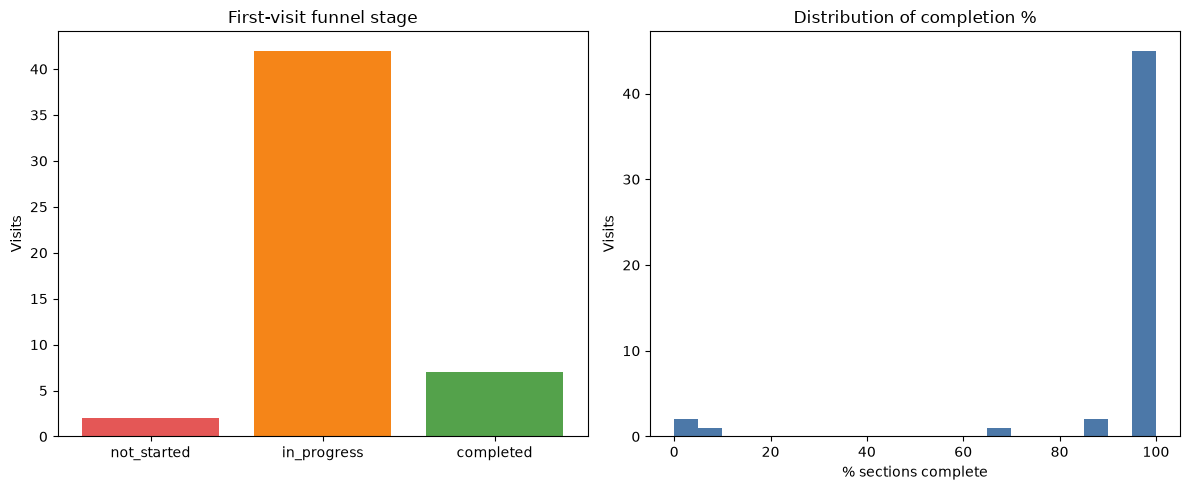

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

colors = {
    "completed": "#54A24B",
    "in_progress": "#F58518",
    "not_started": "#E45756",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stage_counts = df["funnel_stage"].value_counts().reindex(["not_started", "in_progress", "completed"]).fillna(0)
bar_colors = [colors[s] for s in stage_counts.index]
axes[0].bar(stage_counts.index, stage_counts.values, color=bar_colors)
axes[0].set_title("First-visit funnel stage")
axes[0].set_ylabel("Visits")

axes[1].hist(df["pct_complete"], bins=20, color="#4C78A8")
axes[1].set_title("Distribution of completion %")
axes[1].set_xlabel("% sections complete")
axes[1].set_ylabel("Visits")

fig.tight_layout()

os.makedirs("../assets/img", exist_ok=True)
fig.savefig("../assets/img/per_client_completion_pct.png", dpi=150)
plt.show()